# 2311402 - HEX - Lab4

## Sentiment Analysis Exercise  
The goal of the Sentiment Analysis (SA) task is to classify the sentiment within a piece of text. This sentiment can be either binary (positive-negative) or multi-class (a rating scale from 1 to 5).
 
Data: http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz
 
Steps to Solve This Exercise
1. Load data into a pandas DataFrame
2. reprocessing & Vectorizing 
3. Building Model
4. Evaluation

In [33]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil
import zipfile, gzip, urllib, json

## Load the data file into a pandas DataFrame

In [ ]:
# Download file
data_dir = "./data"
url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz"
data_path = os.path.join(data_dir, "reviews_Digital_Music_5.json.gz")

urllib.request.urlretrieve(url, data_path)  

In [10]:
# Extract to the data file
data_dir = "./data"

def unzip_file(path, destination, delete_zip=False):
    if path.endswith(".zip"):
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(path)
        print(f"Extracted zip to {destination}")
    elif path.endswith(".gz"):
        out_file = os.path.join(
            destination, 
            os.path.basename(path).replace(".gz", "")
        )
        with gzip.open(path, 'rb') as f_in:
            with open(out_file, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print(f"Extracted gzip to {out_file}")
    else: 
        print(f"This file format is not accepted")
        return 
    if delete_zip:
        os.remove(path)
        print("Removed compressed file")
        return        
    print("Only unzip file")
    
unzip_file(data_path, data_dir, True)

Extracted gzip to ./data/reviews_Digital_Music_5.json
Removed compressed file


In [16]:
# Load the data
data_path = f"{data_dir}/reviews_Digital_Music_5.json"
def load_data(file_path):
    """Load JSON lines data from file or gz file"""
    data = []
    # Load the JSON lines file
    if os.path.exists(file_path):
        print(f"Loading data from {file_path}...")
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                data.append(json.loads(line))
    else:
        print(f"File not found: {file_path}")
        print("Please ensure the data file is in the ./data directory")
        return None
    
    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} reviews")
    return df

# Load the data
df = load_data(data_path)

Loading data from ./data/reviews_Digital_Music_5.json...
Loaded 64706 reviews


In [17]:
# Display basic info
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head(2))
print("\nRating distribution:")
print(df['overall'].value_counts().sort_index())


Dataset shape: (64706, 9)

Column names: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']

First few rows:
       reviewerID        asin          reviewerName helpful  \
0  A3EBHHCZO6V2A4  5555991584  Amaranth "music fan"  [3, 3]   
1   AZPWAXJG9OJXV  5555991584             bethtexas  [0, 0]   

                                          reviewText  overall  \
0  It's hard to believe "Memory of Trees" came ou...      5.0   
1  A clasically-styled and introverted album, Mem...      5.0   

                    summary  unixReviewTime   reviewTime  
0   Enya's last great album      1158019200  09 12, 2006  
1  Enya at her most elegant       991526400   06 3, 2001  

Rating distribution:
overall
1.0     2791
2.0     3010
3.0     6789
4.0    16536
5.0    35580
Name: count, dtype: int64


## Preprocessing data

In [35]:
# Preprocessing data
import re
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Handle common contractions (important for sentiment)
    contractions = {
        "'nt":"not",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'ve": " have",
        "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    # Keep only letters and spaces (remove numbers, punctuation)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove very short words (length < 2)
    words = [lemmatizer.lemmatize(word) for word in text.split() if len(word) > 1]
    
    return text

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/dikhang_hcmut/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/dikhang_hcmut/nltk_data...


In [36]:
# Apply preprocessing
df['cleaned_review'] = df['reviewText'].apply(preprocess_text)

# Remove empty reviews
df = df[df['cleaned_review'] != '']

print(f"Reviews after cleaning: {len(df)}")

# Create binary sentiment labels (1-3: Negative, 4-5: Positive)
df['sentiment_binary'] = df['overall'].apply(lambda x: 'positive' if x >= 4 else 'negative')
print("\nBinary sentiment distribution:")
print(df['sentiment_binary'].value_counts())

# Multi-class labels (keep original ratings 1-5)
df['sentiment_multiclass'] = df['overall'].astype(int)

Reviews after cleaning: 64705

Binary sentiment distribution:
sentiment_binary
positive    52116
negative    12589
Name: count, dtype: int64


## Feature Extraction

In [ ]:
# Split data once for both binary & multiclass
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y_binary = df['sentiment_binary']
y_multiclass = df['sentiment_multiclass']

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multiclass, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary  # hoặc stratify=y_multiclass nếu muốn cân bằng multi-class
)

# Encode multiclass labels
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train_multi)
y_test_enc = encoder.transform(y_test_multi)

# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,      
    min_df=3,                
    max_df=0.7,              
    ngram_range=(1, 3),      
    stop_words='english',    
    sublinear_tf=True,       
    strip_accents='unicode'  
)


In [52]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training set size: {X_train_tfidf.shape}")
print(f"Testing set size: {X_test_tfidf.shape}")

Training set size: (51764, 10000)
Testing set size: (12941, 10000)


## Build the model

### Binay Classification

In [53]:
from sklearn.linear_model import LogisticRegression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train_bin)
y_pred_lr = lr_model.predict(X_test_tfidf)


Training Logistic Regression...


In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_lr))
cm_lr = confusion_matrix(y_test_bin, y_pred_lr)

Accuracy: 0.8759

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.48      0.60      2518
    positive       0.89      0.97      0.93     10423

    accuracy                           0.88     12941
   macro avg       0.84      0.73      0.76     12941
weighted avg       0.87      0.88      0.86     12941



### Naive Bayes - Binary Classification

In [71]:
from sklearn.naive_bayes import MultinomialNB
print("\nTraining Naive Bayes...")
nb_model = MultinomialNB(alpha=1.0) 
nb_model.fit(X_train_tfidf, y_train_bin)
y_pred_nb = nb_model.predict(X_test_tfidf)


Training Naive Bayes...


In [72]:
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_nb))
cm_nb = confusion_matrix(y_test_bin, y_pred_nb)

Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.24      0.37      2518
    positive       0.84      0.98      0.91     10423

    accuracy                           0.84     12941
   macro avg       0.82      0.61      0.64     12941
weighted avg       0.83      0.84      0.80     12941



### Multi-class Classification

In [64]:
lr_multi = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
print("\nTraining Logistic Regression for MultiClass...")
lr_multi.fit(X_train_tfidf, y_train_enc)

# Predict
y_pred_lr_multi = lr_multi.predict(X_test_tfidf)


Training Logistic Regression for MultiClass...


/home/dikhang_hcmut/miniconda3/envs/pytorch_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [68]:
# Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_lr_multi):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lr_multi, target_names=encoder.classes_.astype(str)))

cm_multi_lr = confusion_matrix(y_test_enc, y_pred_lr_multi)
print("\nConfusion Matrix:")
print(cm_multi_lr)

Accuracy: 0.6284

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.44      0.53       541
           2       0.40      0.11      0.17       612
           3       0.42      0.25      0.31      1365
           4       0.47      0.37      0.41      3403
           5       0.70      0.89      0.78      7020

    accuracy                           0.63     12941
   macro avg       0.53      0.41      0.44     12941
weighted avg       0.59      0.63      0.60     12941


Confusion Matrix:
[[ 239   45   58   48  151]
 [  58   66  176  144  168]
 [  25   38  339  531  432]
 [  12    8  178 1251 1954]
 [  19    6   52  706 6237]]


### Linear SVM - Multi-class Classification

In [69]:
from sklearn.svm import LinearSVC
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train_enc)
y_pred_svm_multi = svm.predict(X_test_tfidf)

In [75]:
# Evaluate SVM model
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_svm_multi):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_svm_multi, target_names=encoder.classes_.astype(str)))

cm_multi_svm = confusion_matrix(y_test_enc, y_pred_svm_multi)
print("\nConfusion Matrix:")
print(cm_multi_svm)

Accuracy: 0.6099

Classification Report:
              precision    recall  f1-score   support

           1       0.58      0.50      0.53       541
           2       0.33      0.17      0.22       612
           3       0.36      0.25      0.29      1365
           4       0.44      0.36      0.40      3403
           5       0.71      0.85      0.77      7020

    accuracy                           0.61     12941
   macro avg       0.48      0.42      0.44     12941
weighted avg       0.58      0.61      0.59     12941


Confusion Matrix:
[[ 268   52   64   40  117]
 [  90  103  159  125  135]
 [  40   91  343  514  377]
 [  28   38  258 1223 1856]
 [  37   25  138  864 5956]]


### Multi-class Naive Bayes

In [78]:
# Multi-class Naive Bayes
print("\nTraining Naive Bayes for Multi-class...")
nb_multi = MultinomialNB(alpha=1.0)
nb_multi.fit(X_train_tfidf, y_train_enc)
y_pred_nb_multi = nb_multi.predict(X_test_tfidf)


Training Naive Bayes for Multi-class...


In [79]:
# Evaluate Naive Bayes model
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_nb_multi):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_nb_multi, target_names=encoder.classes_.astype(str)))

cm_multi_nb = confusion_matrix(y_test_enc, y_pred_nb_multi)
print("\nConfusion Matrix:")
print(cm_multi_nb)

Accuracy: 0.5851

Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.24      0.36       541
           2       0.18      0.00      0.01       612
           3       0.46      0.04      0.07      1365
           4       0.44      0.17      0.25      3403
           5       0.60      0.97      0.74      7020

    accuracy                           0.59     12941
   macro avg       0.48      0.28      0.28     12941
weighted avg       0.53      0.59      0.49     12941


Confusion Matrix:
[[ 128    2   12   33  366]
 [  29    2   33  134  414]
 [   8    5   49  379  924]
 [   3    2   10  584 2804]
 [   7    0    3  201 6809]]


## Visualization the results of models

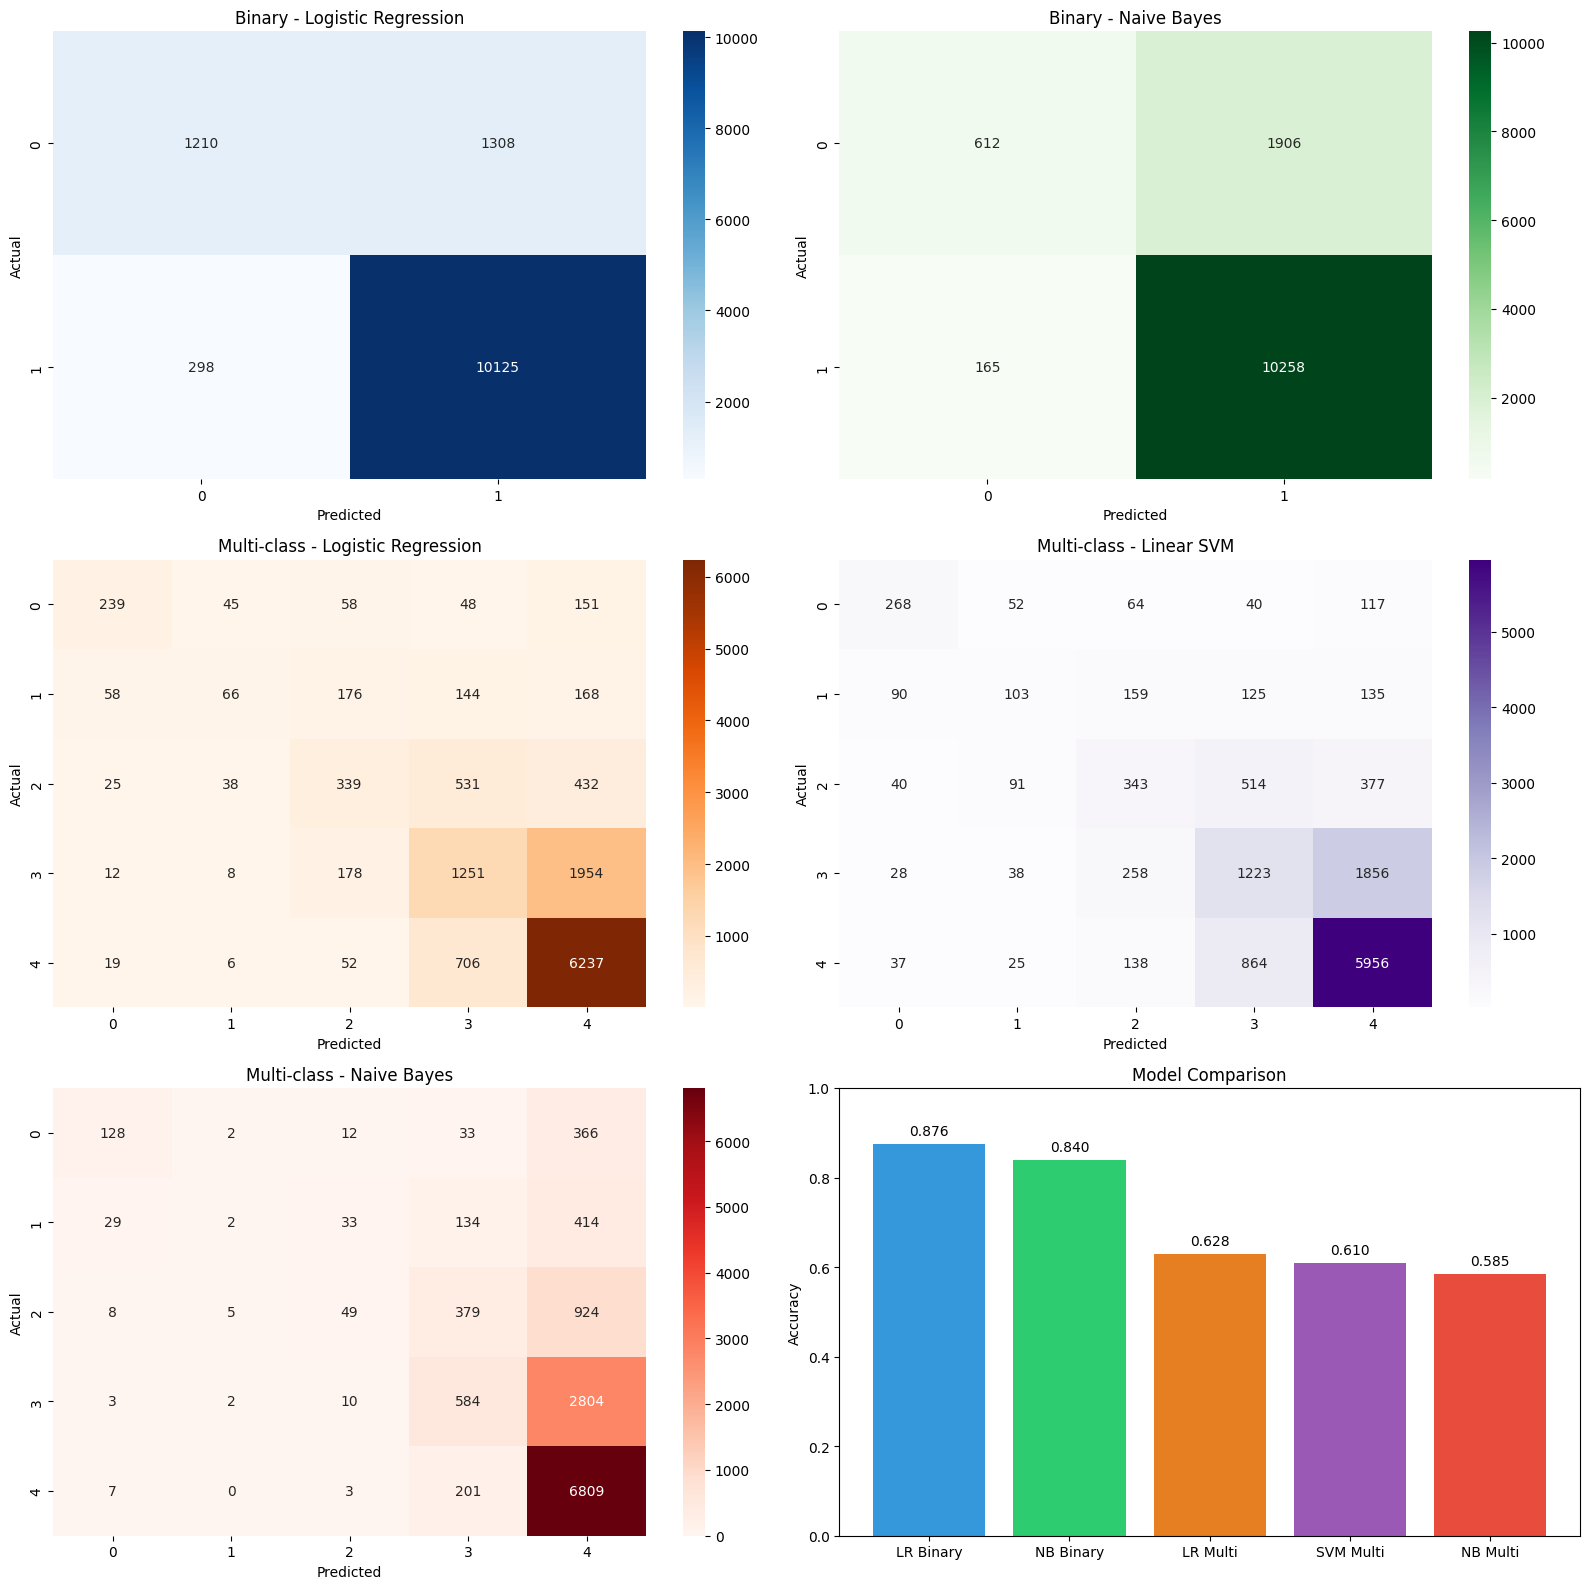


Saved: 'sentiment_analysis_5models.png'


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# 1. Binary Logistic Regression
cm_lr = confusion_matrix(y_test_bin, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Binary - Logistic Regression')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. Binary Naive Bayes
cm_nb = confusion_matrix(y_test_bin, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1])
axes[0, 1].set_title('Binary - Naive Bayes')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 3. Multi-class Logistic Regression
cm_multi_lr = confusion_matrix(y_test_enc, y_pred_lr_multi)
sns.heatmap(cm_multi_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0])
axes[1, 0].set_title('Multi-class - Logistic Regression')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# 4. Multi-class SVM
cm_multi_svm = confusion_matrix(y_test_enc, y_pred_svm_multi)
sns.heatmap(cm_multi_svm, annot=True, fmt='d', cmap='Purples', ax=axes[1, 1])
axes[1, 1].set_title('Multi-class - Linear SVM')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

# 5. Multi-class Naive Bayes
cm_multi_nb = confusion_matrix(y_test_enc, y_pred_nb_multi)
sns.heatmap(cm_multi_nb, annot=True, fmt='d', cmap='Reds', ax=axes[2, 0])
axes[2, 0].set_title('Multi-class - Naive Bayes')
axes[2, 0].set_xlabel('Predicted')
axes[2, 0].set_ylabel('Actual')

# 6. Accuracy Comparison
models = ['LR Binary', 'NB Binary', 'LR Multi', 'SVM Multi', 'NB Multi']
accuracies = [
    accuracy_score(y_test_bin, y_pred_lr),
    accuracy_score(y_test_bin, y_pred_nb),
    accuracy_score(y_test_enc, y_pred_lr_multi),
    accuracy_score(y_test_enc, y_pred_svm_multi),
    accuracy_score(y_test_enc, y_pred_nb_multi)
]
axes[2, 1].bar(models, accuracies, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c'])
axes[2, 1].set_ylabel('Accuracy')
axes[2, 1].set_title('Model Comparison')
axes[2, 1].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[2, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('sentiment_analysis_5models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: 'sentiment_analysis_5models.png'")
